In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [96]:
df = pd.read_csv('hotel_cleaned.csv')

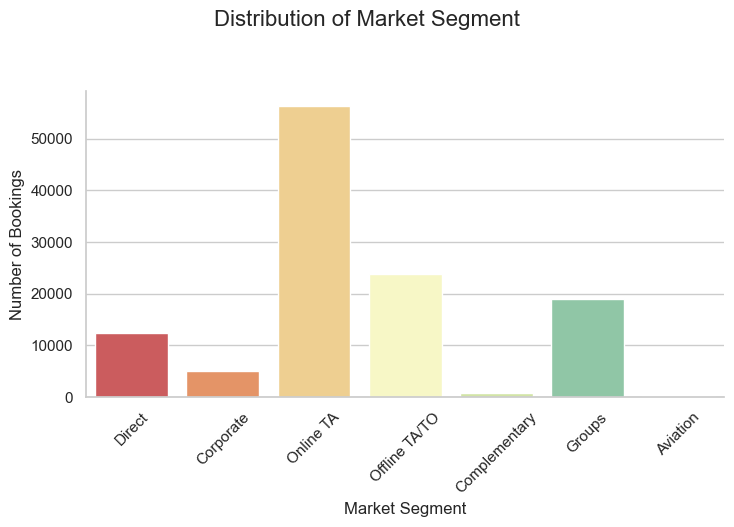

In [33]:
g = sb.catplot(data=df, x='market_segment', kind='count', height=5, aspect=1.5,
               hue='market_segment', palette='Spectral')
g.set_axis_labels("Market Segment", "Number of Bookings")
g.set_xticklabels(rotation=45)
g.fig.suptitle('Distribution of Market Segment', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

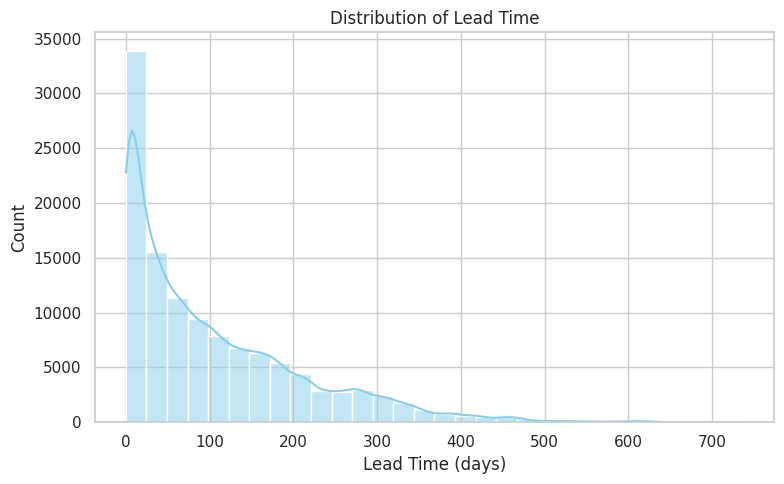

In [26]:
plt.figure(figsize=(8,5))
sb.histplot(df['lead_time'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27368\3378952553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


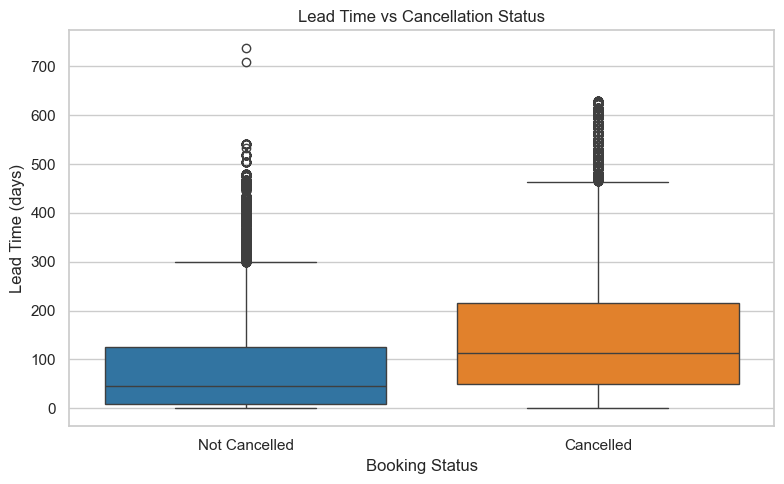

In [151]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})
sb.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sb.boxplot(
    data=df,
    x='cancellation_label',
    y='lead_time',
    palette=['tab:blue', 'tab:orange'],
    order=['Not Cancelled', 'Cancelled']
)

plt.title('Lead Time vs Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

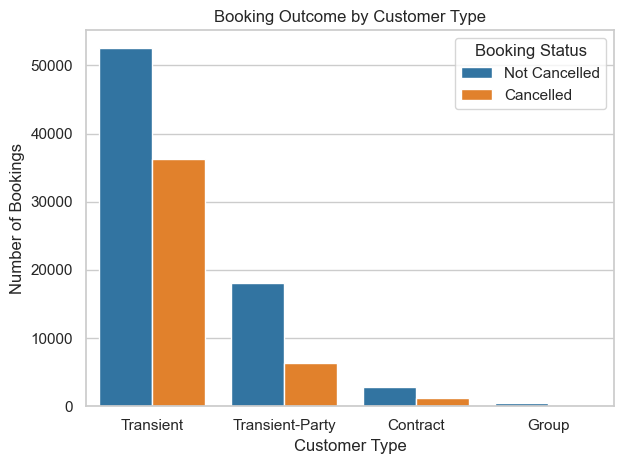

In [149]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})
ct_counts = df.groupby(['customer_type', 'cancellation_label']).size().reset_index(name='count')
order = df['customer_type'].value_counts().index
ct_counts['customer_type'] = pd.Categorical(ct_counts['customer_type'], categories=order, ordered=True)

sb.set_palette(['tab:blue', 'tab:orange'])
sb.barplot(
    data=ct_counts,
    x='customer_type',
    y='count',
    hue='cancellation_label',
    hue_order=['Not Cancelled', 'Cancelled']
)

plt.title('Booking Outcome by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

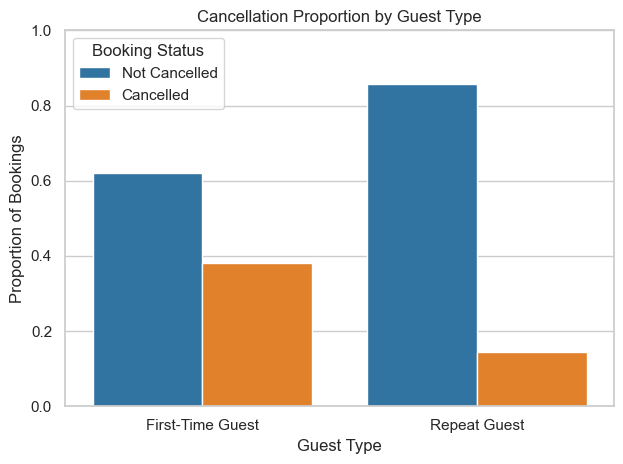

In [150]:
df['repeat_label'] = df['is_repeated_guest'].map({0: 'First-Time Guest', 1: 'Repeat Guest'})
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

cross = pd.crosstab(df['repeat_label'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']]
cross = cross.reset_index().melt(id_vars='repeat_label', var_name='cancellation_label', value_name='proportion')

sb.set_palette(['tab:blue', 'tab:orange'])
sb.barplot(data=cross, x='repeat_label', y='proportion', hue='cancellation_label')

plt.title('Cancellation Proportion by Guest Type')
plt.xlabel('Guest Type')
plt.ylabel('Proportion of Bookings')
plt.ylim(0, 1)
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

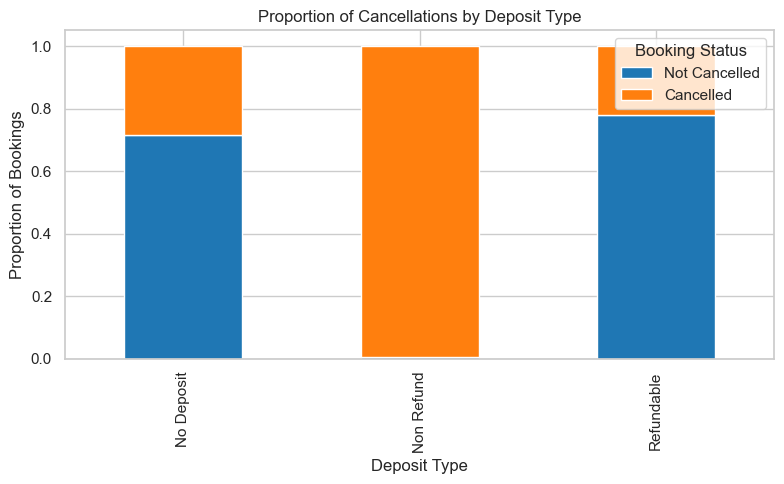

In [148]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})
cross = pd.crosstab(df['deposit_type'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']]
cross.plot(kind='bar', stacked=True, color=['tab:blue', 'tab:orange'], figsize=(8, 5))

plt.title('Proportion of Cancellations by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Proportion of Bookings')
plt.legend(title='Booking Status', loc='upper right')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27368\2667131651.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


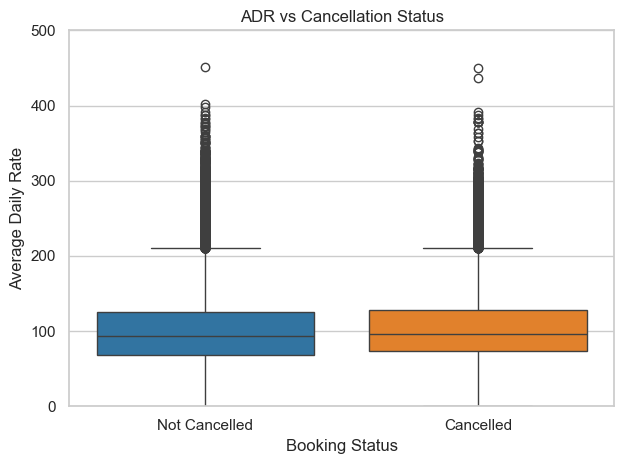

In [156]:
sb.boxplot(
    data=df,
    x='cancellation_label',
    y='adr',
    palette=['tab:blue', 'tab:orange'],
    order=['Not Cancelled', 'Cancelled']
)

plt.ylim(0, 500) 
plt.title('ADR vs Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Average Daily Rate')
plt.tight_layout()
plt.show()

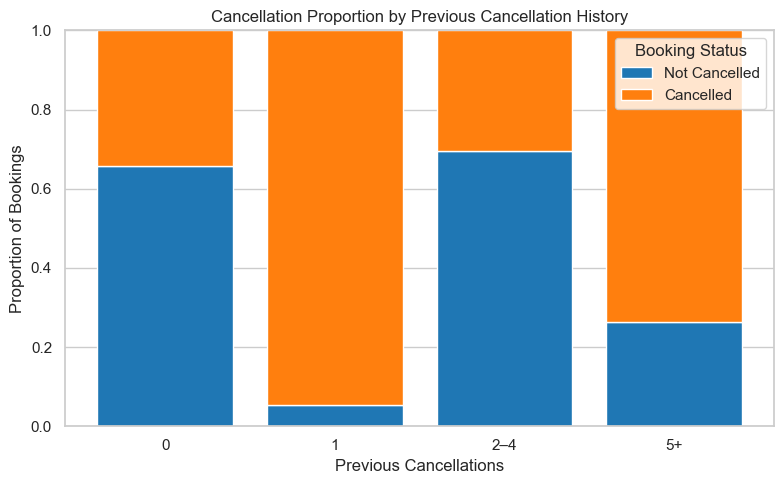

In [147]:
def bin_prev_cancel(x):
    if x == 0:
        return '0'
    elif x == 1:
        return '1'
    elif 2 <= x <= 4:
        return '2–4'
    else:
        return '5+'

df['prev_cancel_bin'] = df['previous_cancellations'].apply(bin_prev_cancel)
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

cross = pd.crosstab(df['prev_cancel_bin'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']]  
fig, ax = plt.subplots(figsize=(8, 5))

bottom_vals = None
colors = ['tab:blue', 'tab:orange']

for i, label in enumerate(cross.columns):
    ax.bar(
        cross.index,
        cross[label],
        label=label,
        bottom=bottom_vals,
        color=colors[i]
    )
    bottom_vals = cross[label] if bottom_vals is None else bottom_vals + cross[label]

ax.set_title('Cancellation Proportion by Previous Cancellation History')
ax.set_xlabel('Previous Cancellations')
ax.set_ylabel('Proportion of Bookings')
ax.set_ylim(0, 1)
ax.legend(title='Booking Status')
plt.tight_layout()
plt.show()

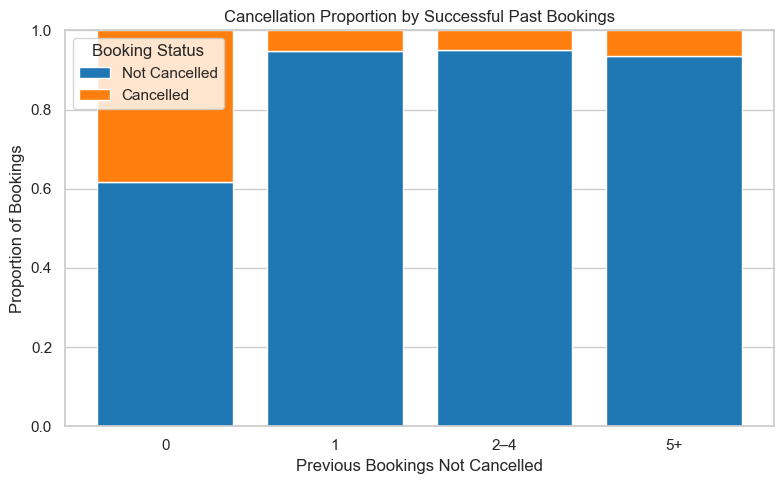

In [144]:
def bin_prev_bookings(x):
    if x == 0:
        return '0'
    elif x == 1:
        return '1'
    elif 2 <= x <= 4:
        return '2–4'
    else:
        return '5+'

df['prev_bookings_bin'] = df['previous_bookings_not_canceled'].apply(bin_prev_bookings)
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

cross = pd.crosstab(df['prev_bookings_bin'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']] 

fig, ax = plt.subplots(figsize=(8, 5))
bottom_vals = None
colors = ['tab:blue', 'tab:orange']

for i, label in enumerate(cross.columns):
    ax.bar(
        cross.index,
        cross[label],
        bottom=bottom_vals,
        label=label,
        color=colors[i]
    )
    bottom_vals = cross[label] if bottom_vals is None else bottom_vals + cross[label]

ax.set_title('Cancellation Proportion by Successful Past Bookings')
ax.set_xlabel('Previous Bookings Not Cancelled')
ax.set_ylabel('Proportion of Bookings')
ax.set_ylim(0, 1)
ax.legend(title='Booking Status')
plt.tight_layout()
plt.show()

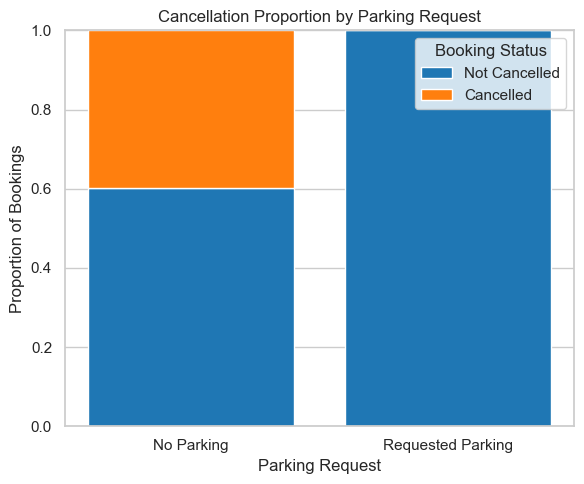

In [145]:
df['parking_label'] = df['required_car_parking_spaces'].apply(lambda x: 'No Parking' if x == 0 else 'Requested Parking')
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})
cross = pd.crosstab(df['parking_label'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']] 

fig, ax = plt.subplots(figsize=(6, 5))
bottom_vals = None
colors = ['tab:blue', 'tab:orange']

for i, label in enumerate(cross.columns):
    ax.bar(
        cross.index,
        cross[label],
        bottom=bottom_vals,
        label=label,
        color=colors[i]
    )
    bottom_vals = cross[label] if bottom_vals is None else bottom_vals + cross[label]

ax.set_title('Cancellation Proportion by Parking Request')
ax.set_xlabel('Parking Request')
ax.set_ylabel('Proportion of Bookings')
ax.set_ylim(0, 1)
ax.legend(title='Booking Status')
plt.tight_layout()
plt.show()

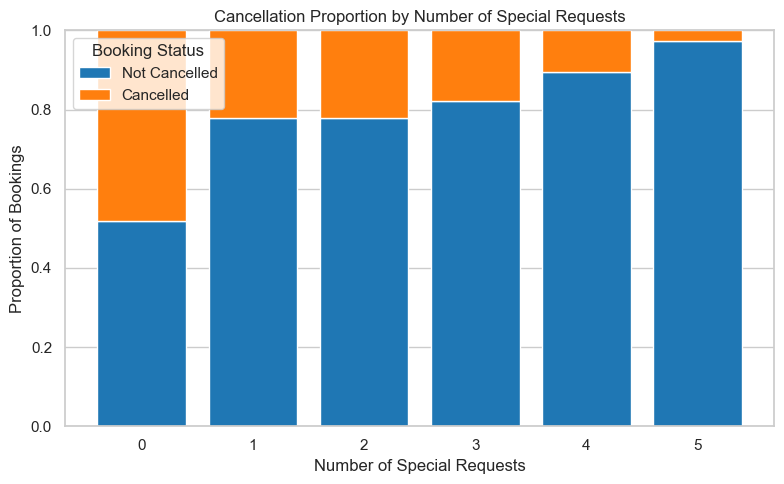

In [143]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

cross = pd.crosstab(df['total_of_special_requests'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']]  

fig, ax = plt.subplots(figsize=(8, 5))
bottom_vals = None
colors = ['tab:blue', 'tab:orange']

for i, label in enumerate(cross.columns):
    ax.bar(
        cross.index,
        cross[label],
        bottom=bottom_vals,
        label=label,
        color=colors[i]
    )
    bottom_vals = cross[label] if bottom_vals is None else bottom_vals + cross[label]

ax.set_title('Cancellation Proportion by Number of Special Requests')
ax.set_xlabel('Number of Special Requests')
ax.set_ylabel('Proportion of Bookings')
ax.set_ylim(0, 1)
ax.legend(title='Booking Status')
plt.tight_layout()
plt.show()

In [141]:
def classify_stay(row):
    if row['stays_in_week_nights'] > 0 and row['stays_in_weekend_nights'] == 0:
        return 'Weekday Only'
    elif row['stays_in_week_nights'] == 0 and row['stays_in_weekend_nights'] > 0:
        return 'Weekend Only'
    elif row['stays_in_week_nights'] > 0 and row['stays_in_weekend_nights'] > 0:
        return 'Both'
    else:
        return 'No Stay' 

df['stay_type'] = df.apply(classify_stay, axis=1)
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

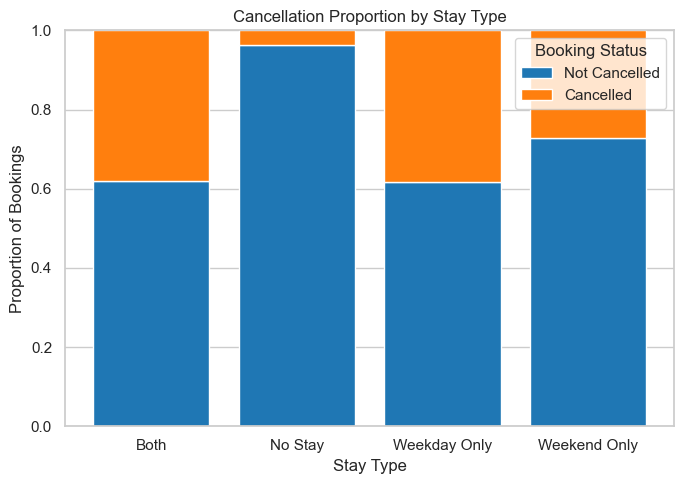

In [142]:
cross = pd.crosstab(df['stay_type'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']]  

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['tab:blue', 'tab:orange']
bottom_vals = None

for i, label in enumerate(cross.columns):
    ax.bar(
        cross.index,
        cross[label],
        bottom=bottom_vals,
        color=colors[i],
        label=label
    )
    bottom_vals = cross[label] if bottom_vals is None else bottom_vals + cross[label]

ax.set_title('Cancellation Proportion by Stay Type')
ax.set_xlabel('Stay Type')
ax.set_ylabel('Proportion of Bookings')
ax.set_ylim(0, 1)
ax.legend(title='Booking Status')
plt.tight_layout()
plt.show()

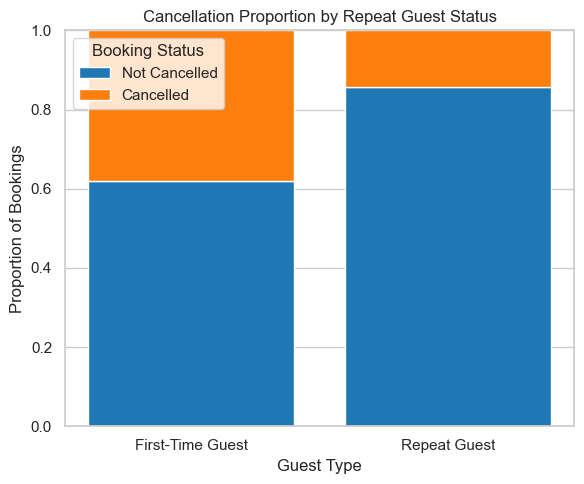

In [140]:
df['repeat_label'] = df['is_repeated_guest'].map({0: 'First-Time Guest', 1: 'Repeat Guest'})
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

cross = pd.crosstab(df['repeat_label'], df['cancellation_label'], normalize='index')
cross = cross[['Not Cancelled', 'Cancelled']] 

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['tab:blue', 'tab:orange']
bottom_vals = None

for i, label in enumerate(cross.columns):
    ax.bar(
        cross.index,
        cross[label],
        bottom=bottom_vals,
        label=label,
        color=colors[i]
    )
    bottom_vals = cross[label] if bottom_vals is None else bottom_vals + cross[label]

ax.set_title('Cancellation Proportion by Repeat Guest Status')
ax.set_xlabel('Guest Type')
ax.set_ylabel('Proportion of Bookings')
ax.set_ylim(0, 1)
ax.legend(title='Booking Status')
plt.tight_layout()
plt.show()

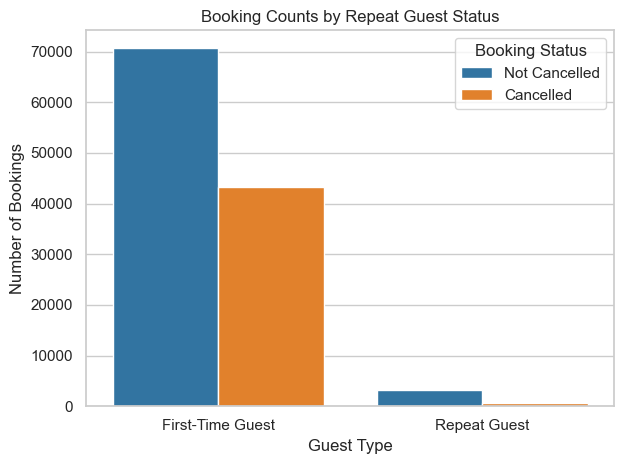

In [84]:
sb.countplot(data=df, x='repeat_label', hue='cancellation_label', palette=['tab:blue', 'tab:orange'])
plt.title('Booking Counts by Repeat Guest Status')
plt.xlabel('Guest Type')
plt.ylabel('Number of Bookings')
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

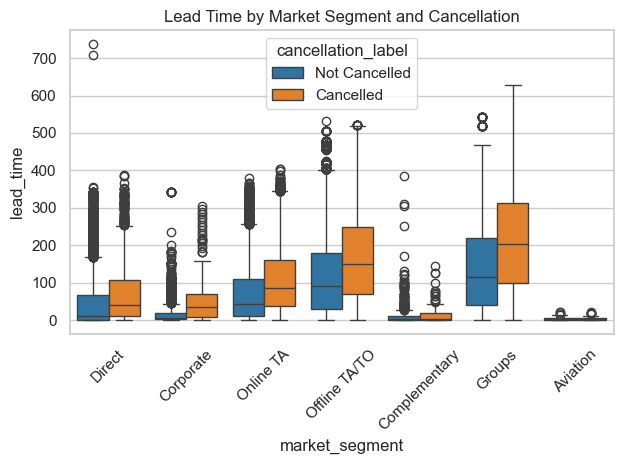

In [86]:
sb.boxplot(data=df, x='market_segment', y='lead_time', hue='cancellation_label',
           palette=['tab:blue', 'tab:orange'])
plt.xticks(rotation=45)
plt.title('Lead Time by Market Segment and Cancellation')
plt.tight_layout()
plt.show()

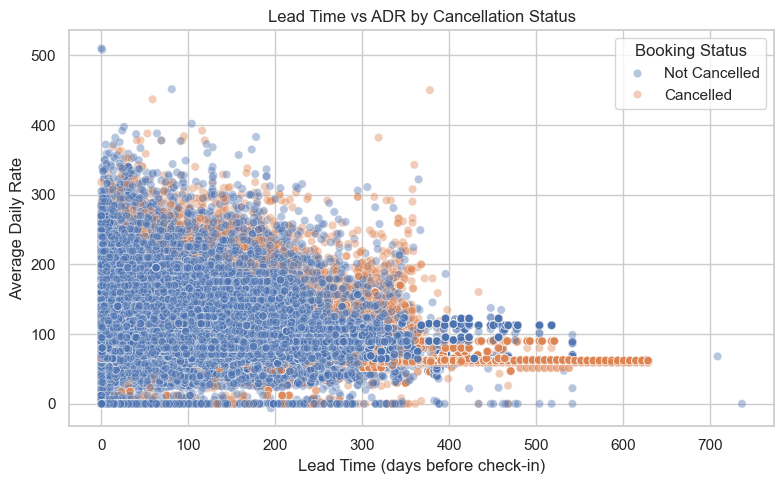

In [152]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})
plt.figure(figsize=(8, 5))
sb.scatterplot(data=df, x='lead_time', y='adr', hue='cancellation_label', alpha=0.4)

plt.title('Lead Time vs ADR by Cancellation Status')
plt.xlabel('Lead Time (days before check-in)')
plt.ylabel('Average Daily Rate')
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27368\2674473217.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['lead_bin', 'cancellation_label'])['adr'].mean().unstack()


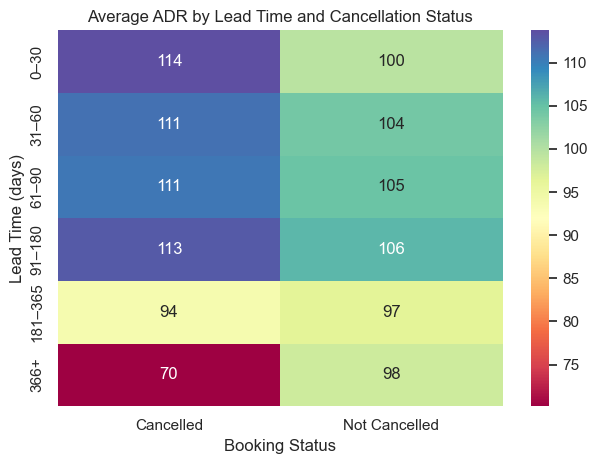

In [155]:
df['lead_bin'] = pd.cut(df['lead_time'], bins=[0, 30, 60, 90, 180, 365, 600], 
                        labels=['0–30', '31–60', '61–90', '91–180', '181–365', '366+'])

pivot = df.groupby(['lead_bin', 'cancellation_label'])['adr'].mean().unstack()

sb.heatmap(pivot, annot=True, fmt=".0f", cmap="Spectral")
plt.title('Average ADR by Lead Time and Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

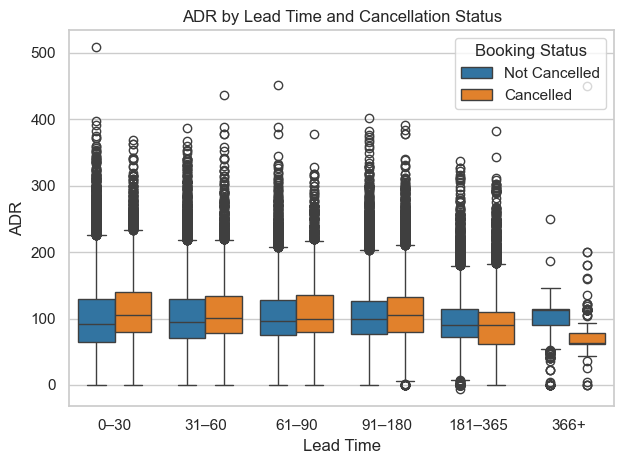

In [157]:
sb.boxplot(data=df, x='lead_bin', y='adr', hue='cancellation_label', palette=['tab:blue', 'tab:orange'])
plt.title('ADR by Lead Time and Cancellation Status')
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27368\1152973728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_rate = df.groupby('lead_bin')['is_canceled'].mean().reset_index()


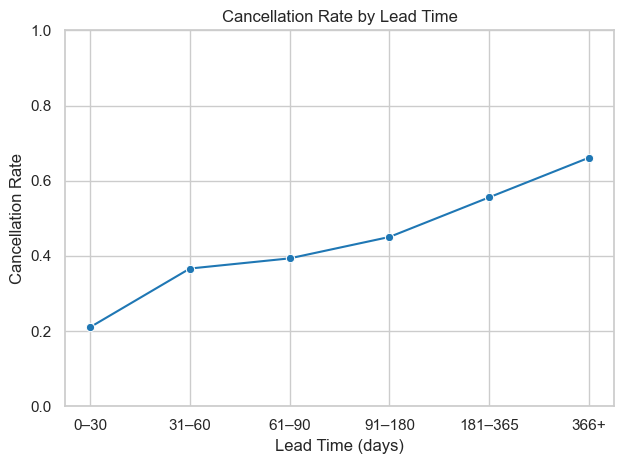

In [101]:
cancel_rate = df.groupby('lead_bin')['is_canceled'].mean().reset_index()

sb.lineplot(data=cancel_rate, x='lead_bin', y='is_canceled', marker='o')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27368\461829117.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['lead_bin', 'year'])['is_canceled']


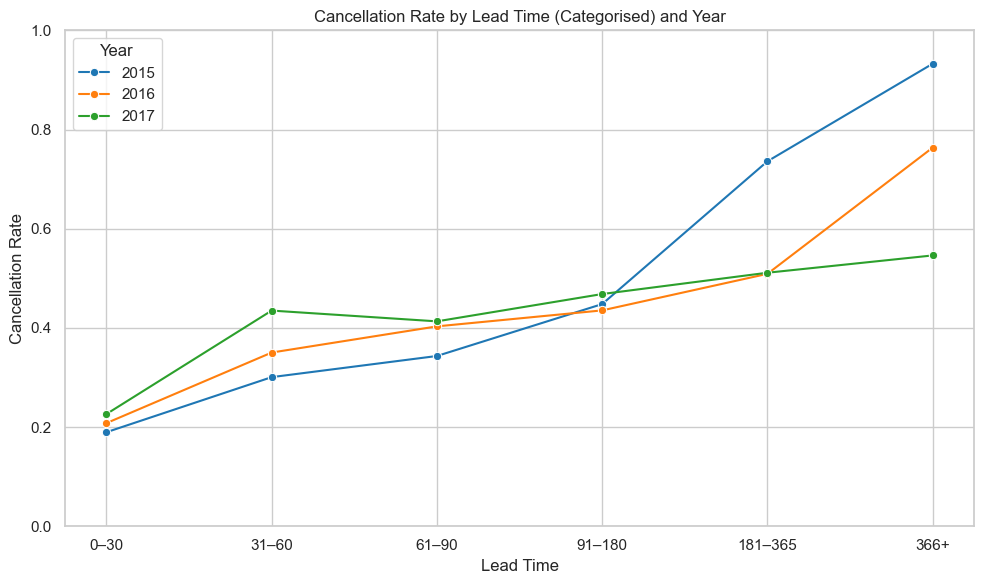

In [132]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

df['year'] = df['arrival_date'].dt.year

df['lead_bin'] = pd.cut(df['lead_time'], 
                        bins=[0, 30, 60, 90, 180, 365, 800],
                        labels=['0–30', '31–60', '61–90', '91–180', '181–365', '366+'])

binned = (
    df.groupby(['lead_bin', 'year'])['is_canceled']
    .mean()
    .reset_index(name='cancellation_rate')
)

plt.figure(figsize=(10, 6))
sb.lineplot(data=binned, x='lead_bin', y='cancellation_rate', hue='year', marker='o', palette='tab10')

plt.title('Cancellation Rate by Lead Time (Categorised) and Year')
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

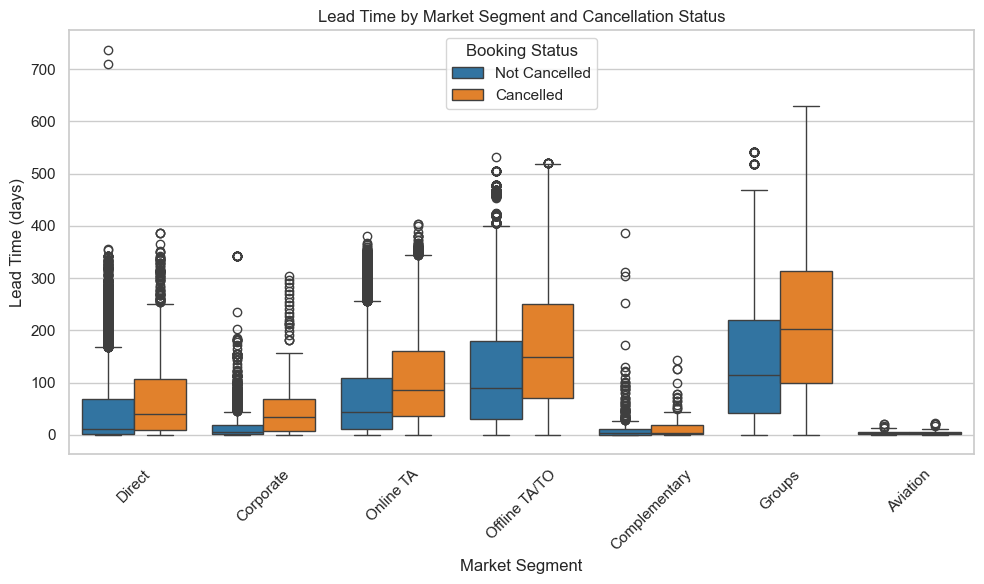

In [133]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

plt.figure(figsize=(10, 6))
sb.boxplot(data=df, x='market_segment', y='lead_time', hue='cancellation_label',
           palette=['tab:blue', 'tab:orange'])
plt.title('Lead Time by Market Segment and Cancellation Status')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time (days)')
plt.xticks(rotation=45)
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27368\1505605176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=cancel_rate_by_segment, x='market_segment', y='is_canceled', palette='Spectral')


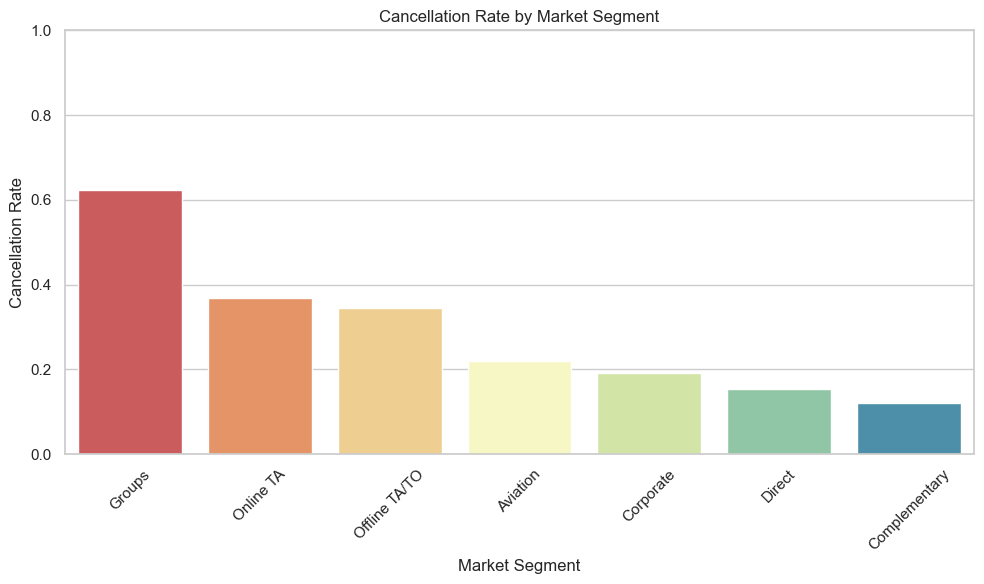

In [134]:
cancel_rate_by_segment = (
    df.groupby('market_segment')['is_canceled']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sb.barplot(data=cancel_rate_by_segment, x='market_segment', y='is_canceled', palette='Spectral')

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

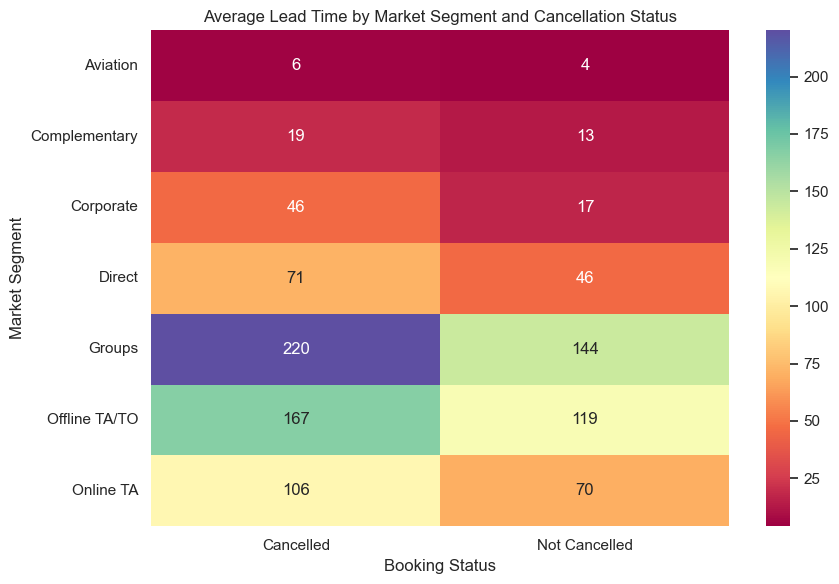

In [135]:
df['cancellation_label'] = df['is_canceled'].map({0: 'Not Cancelled', 1: 'Cancelled'})

heatmap_data = df.groupby(['market_segment', 'cancellation_label'])['lead_time'].mean().unstack()
plt.figure(figsize=(9, 6))
sb.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Spectral")

plt.title('Average Lead Time by Market Segment and Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Market Segment')
plt.tight_layout()
plt.show()

In [136]:
df.groupby('deposit_type')['is_canceled'].mean()

deposit_type
No Deposit    0.285995
Non Refund    0.993552
Refundable    0.222222
Name: is_canceled, dtype: float64

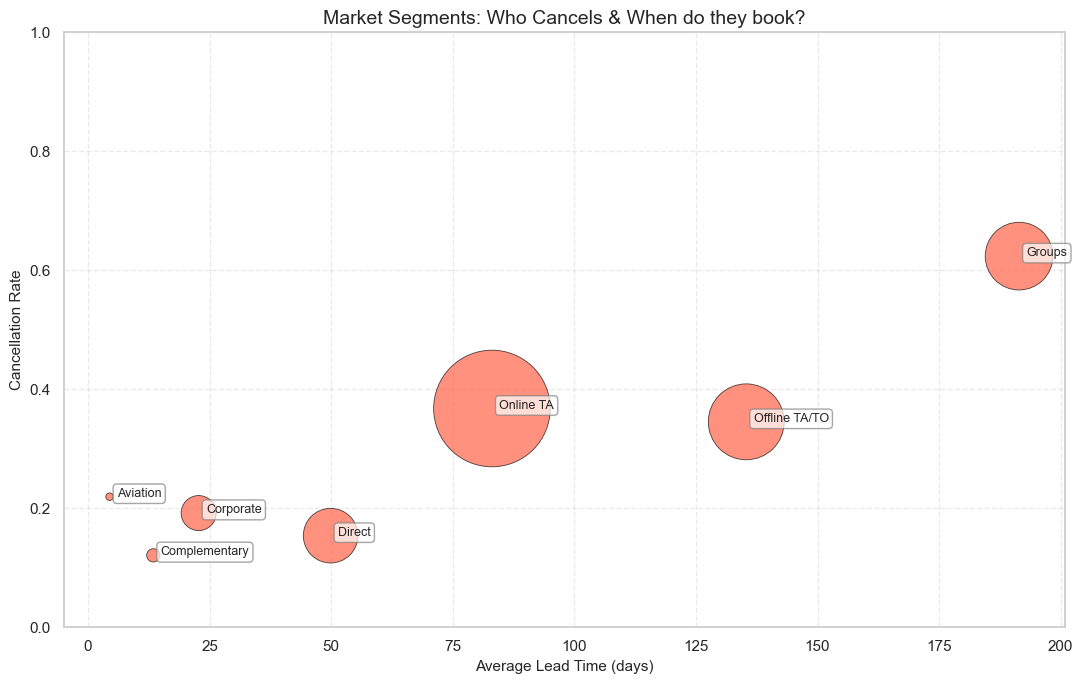

In [137]:
summary = df.groupby('market_segment').agg(
    avg_lead_time=('lead_time', 'mean'),
    cancellation_rate=('is_canceled', 'mean'),
    booking_count=('is_canceled', 'count')  
).reset_index()

sb.set(style="whitegrid")
plt.figure(figsize=(11, 7))

plt.scatter(
    summary['avg_lead_time'],
    summary['cancellation_rate'],
    s=summary['booking_count'] / 8, 
    c='tomato',                       
    alpha=0.7,
    edgecolors='black',
    linewidth=0.6
)

for i, row in summary.iterrows():
    plt.text(
        row['avg_lead_time'] + 1.5,
        row['cancellation_rate'],
        row['market_segment'],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor='gray', alpha=0.7)
    )

plt.title('Market Segments: Who Cancels & When do they book?', fontsize=14)
plt.xlabel('Average Lead Time (days)', fontsize=11)
plt.ylabel('Cancellation Rate', fontsize=11)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

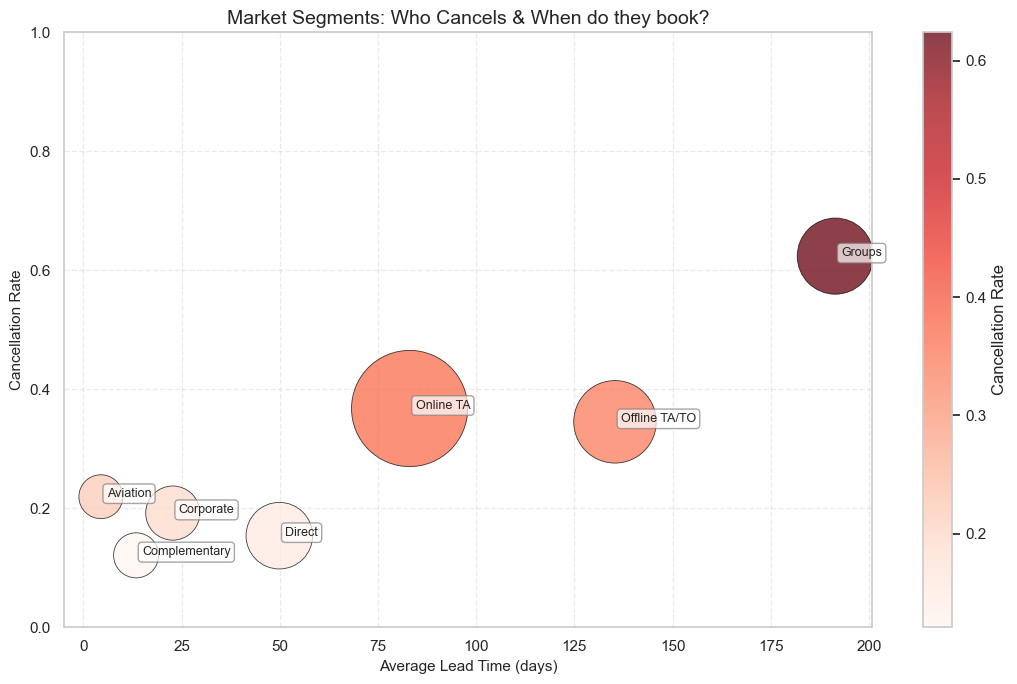

In [131]:
summary = df.groupby('market_segment').agg(
    avg_lead_time=('lead_time', 'mean'),
    cancellation_rate=('is_canceled', 'mean'),
    booking_count=('is_canceled', 'count')
).reset_index()

scaled_sizes = np.interp(
    summary['booking_count'],
    (summary['booking_count'].min(), summary['booking_count'].max()),
    (1000, 7000)  
)

sb.set(style="whitegrid")
plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    summary['avg_lead_time'],
    summary['cancellation_rate'],
    s=scaled_sizes,
    c=summary['cancellation_rate'], 
    cmap='Reds',
    alpha=0.75,
    edgecolors='black',
    linewidth=0.6
)

for i, row in summary.iterrows():
    plt.text(
        row['avg_lead_time'] + 1.5,
        row['cancellation_rate'],
        row['market_segment'],
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor='gray', alpha=0.7)
    )

plt.title('Market Segments: Who Cancels & When do they book?', fontsize=14)
plt.xlabel('Average Lead Time (days)', fontsize=11)
plt.ylabel('Cancellation Rate', fontsize=11)
plt.ylim(0, 1)
plt.colorbar(label='Cancellation Rate')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()